In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [39]:
df = pd.read_csv('DailyDelhiClimateTest.csv')
print(f"Dataset shape: {df.shape}")
print("\nFirst few rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())

Dataset shape: (114, 5)

First few rows:
         date   meantemp   humidity  wind_speed  meanpressure
0  2017-01-01  15.913043  85.869565    2.743478     59.000000
1  2017-01-02  18.500000  77.222222    2.894444   1018.277778
2  2017-01-03  17.111111  81.888889    4.016667   1018.333333
3  2017-01-04  18.700000  70.050000    4.545000   1015.700000
4  2017-01-05  18.388889  74.944444    3.300000   1014.333333

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          114 non-null    object 
 1   meantemp      114 non-null    float64
 2   humidity      114 non-null    float64
 3   wind_speed    114 non-null    float64
 4   meanpressure  114 non-null    float64
dtypes: float64(4), object(1)
memory usage: 4.6+ KB
None


In [38]:
print("DATA CLEANING")

# Check for missing values
print(f"\nMissing values before cleaning:\n{df.isnull().sum()}")

# Handle missing values
df = df.dropna() 
print(f"\nDataset shape after removing NaN: {df.shape}")

# Convert date to datetime
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')
df = df.sort_values('date').reset_index(drop=True)

# Remove duplicates
initial_shape = df.shape[0]
df = df.drop_duplicates()
print(f"Rows removed due to duplicates: {initial_shape - df.shape[0]}")

# Check for outliers using IQR method
print("\nChecking for outliers:")
for col in ['meantemp', 'humidity', 'wind_speed', 'meanpressure']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))).sum()
    print(f"{col}: {outliers} outliers detected")

print("\nCleaned Dataset Statistics:")
print(df[['meantemp', 'humidity', 'wind_speed', 'meanpressure']].describe())

DATA CLEANING

Missing values before cleaning:
date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

Dataset shape after removing NaN: (114, 5)
Rows removed due to duplicates: 0

Checking for outliers:
meantemp: 0 outliers detected
humidity: 0 outliers detected
wind_speed: 2 outliers detected
meanpressure: 1 outliers detected

Cleaned Dataset Statistics:
         meantemp    humidity  wind_speed  meanpressure
count  114.000000  114.000000  114.000000    114.000000
mean    21.713079   56.258362    8.143924   1004.035090
std      6.360072   19.068083    3.588049     89.474692
min     11.000000   17.750000    1.387500     59.000000
25%     16.437198   39.625000    5.563542   1007.437500
50%     19.875000   57.750000    8.069444   1012.739316
75%     27.705357   71.902778   10.068750   1016.739583
max     34.500000   95.833333   19.314286   1022.809524


EXPLORATORY DATA ANALYSIS


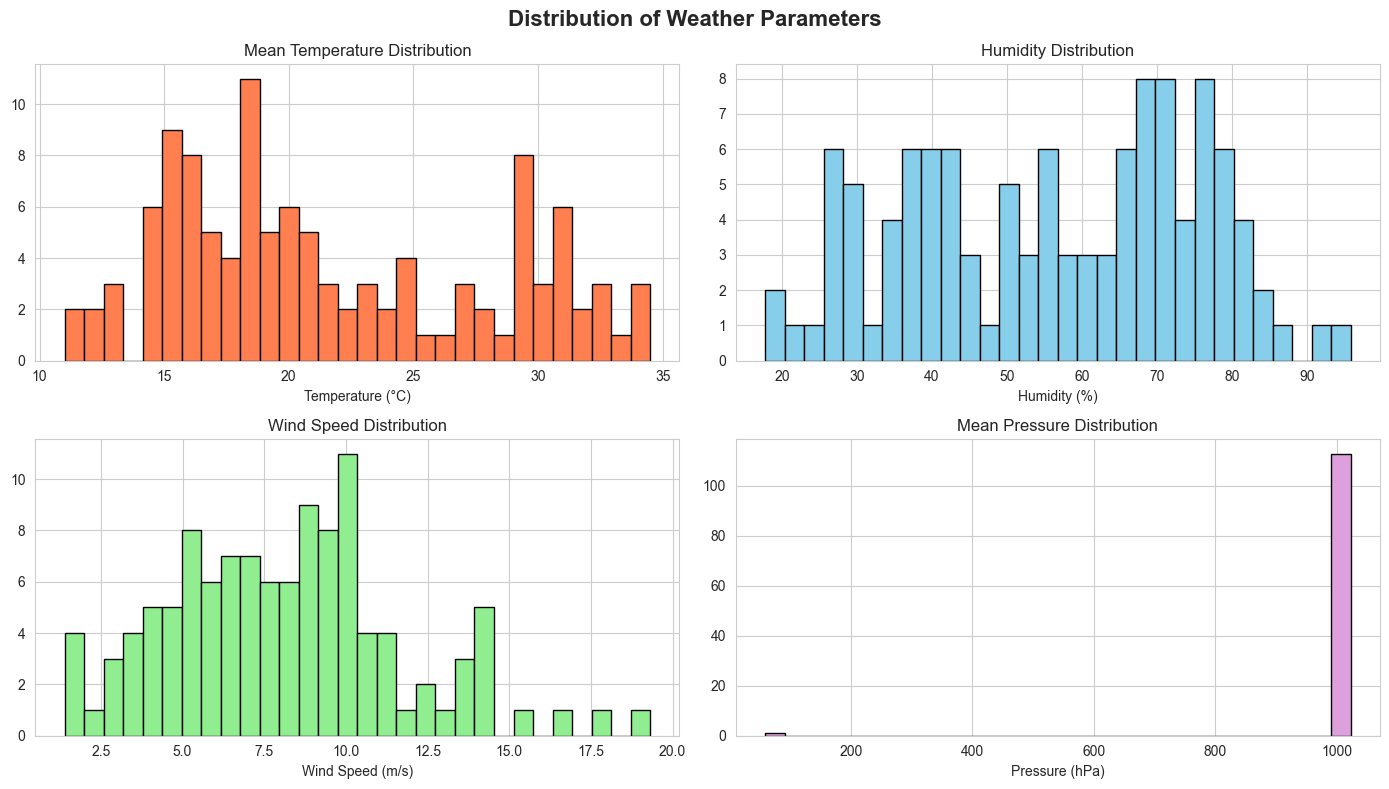

In [37]:
print("EXPLORATORY DATA ANALYSIS")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Distribution of Weather Parameters', fontsize=16, fontweight='bold')

axes[0, 0].hist(df['meantemp'], bins=30, color='coral', edgecolor='black')
axes[0, 0].set_title('Mean Temperature Distribution')
axes[0, 0].set_xlabel('Temperature (°C)')

axes[0, 1].hist(df['humidity'], bins=30, color='skyblue', edgecolor='black')
axes[0, 1].set_title('Humidity Distribution')
axes[0, 1].set_xlabel('Humidity (%)')

axes[1, 0].hist(df['wind_speed'], bins=30, color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Wind Speed Distribution')
axes[1, 0].set_xlabel('Wind Speed (m/s)')

axes[1, 1].hist(df['meanpressure'], bins=30, color='plum', edgecolor='black')
axes[1, 1].set_title('Mean Pressure Distribution')
axes[1, 1].set_xlabel('Pressure (hPa)')

plt.tight_layout()
plt.savefig('01_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

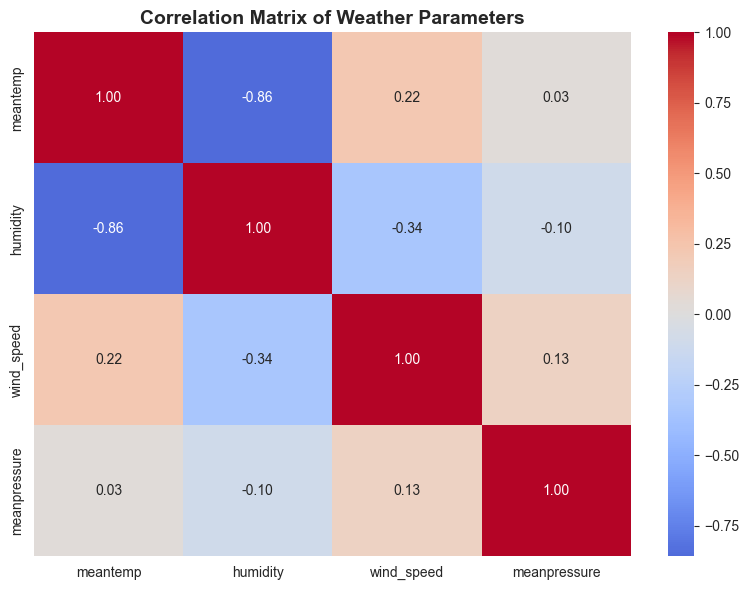

In [8]:
# Correlation analysis
fig, ax = plt.subplots(figsize=(8, 6))
corr_matrix = df[['meantemp', 'humidity', 'wind_speed', 'meanpressure']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix of Weather Parameters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_correlation.png', dpi=300, bbox_inches='tight')
plt.show()


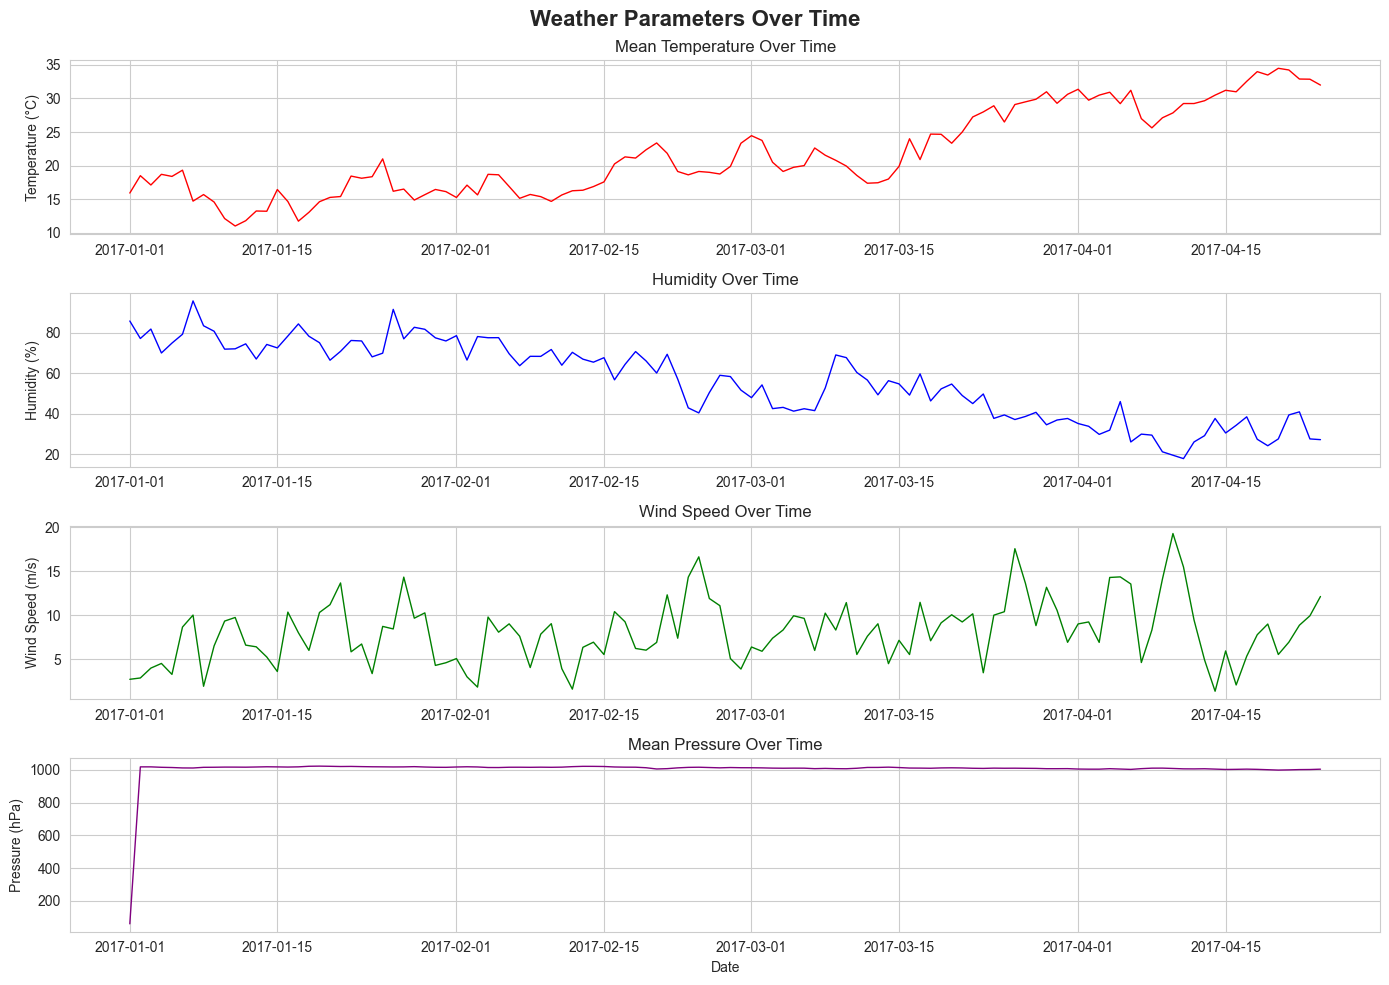

In [36]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
fig.suptitle('Weather Parameters Over Time', fontsize=16, fontweight='bold')

axes[0].plot(df['date'], df['meantemp'], color='red', linewidth=1)
axes[0].set_title('Mean Temperature Over Time')
axes[0].set_ylabel('Temperature (°C)')

axes[1].plot(df['date'], df['humidity'], color='blue', linewidth=1)
axes[1].set_title('Humidity Over Time')
axes[1].set_ylabel('Humidity (%)')

axes[2].plot(df['date'], df['wind_speed'], color='green', linewidth=1)
axes[2].set_title('Wind Speed Over Time')
axes[2].set_ylabel('Wind Speed (m/s)')

axes[3].plot(df['date'], df['meanpressure'], color='purple', linewidth=1)
axes[3].set_title('Mean Pressure Over Time')
axes[3].set_ylabel('Pressure (hPa)')
axes[3].set_xlabel('Date')

plt.tight_layout()
plt.savefig('03_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

In [35]:
X = df[['humidity', 'wind_speed', 'meanpressure']].values
y = df['meantemp'].values

scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

print(f"Features shape: {X_scaled.shape}")
print(f"Target shape: {y_scaled.shape}")

Features shape: (114, 3)
Target shape: (114,)


In [33]:
print("TRAIN-TEST SPLIT")

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

TRAIN-TEST SPLIT
Training set size: 91
Testing set size: 23


In [32]:
print("MODEL TRAINING")

# Train Linear Regression
print("\nTraining Linear Regression...")
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Train Random Forest
print("Training Random Forest...")
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)

print("Models trained successfully!")

MODEL TRAINING

Training Linear Regression...
Training Random Forest...
Models trained successfully!


In [31]:
# PREDICTIONS
print("MAKING PREDICTIONS")

y_pred_lr = model_lr.predict(X_test)
y_pred_rf = model_rf.predict(X_test)

# Inverse transform predictions to original scale
y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()
print(y_test_original)
y_pred_lr_original = scaler_y.inverse_transform(y_pred_lr.reshape(-1, 1)).ravel()
print(y_pred_lr_original)
y_pred_rf_original = scaler_y.inverse_transform(y_pred_rf.reshape(-1, 1)).ravel()
print(y_pred_rf_original)

MAKING PREDICTIONS
[27.25       18.38888889 14.66666667 18.53333333 11.         17.57142857
 17.375      21.54545455 21.3        11.78947368 27.125      16.88888889
 26.5        32.875      14.61904762 15.91304348 18.         16.5
 28.         18.625      30.5        29.75       13.23529412]
[ 25.02808544  18.19208555  17.60855033  22.88846716  16.88498911
  15.61267376  20.52662916  24.3225068   18.24963623  16.90827323
  27.97181537  17.74217394  25.8046282   32.07608472  12.94321973
 562.64583041  19.70437     15.11729922  25.15688446  21.98847595
  29.55273777  29.94228609  17.40528468]
[21.913977   17.84451184 15.29700496 22.73445147 15.0798881  16.83393572
 18.18964138 22.45508383 16.69105505 16.1295384  27.01709524 18.71860979
 28.92091667 32.42813889 16.19547454 22.12936994 18.19109717 16.75098217
 23.58989164 18.5126439  31.78069048 31.47943651 17.08739586]


In [28]:
print("MODEL EVALUATION")

def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{model_name}:")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MSE:  {mse:.4f}")
    print(f"  R²:   {r2:.4f}")
    
    return {'MAE': mae, 'RMSE': rmse, 'MSE': mse, 'R2': r2}

metrics_lr = evaluate_model(y_test_original, y_pred_lr_original, "Linear Regression")
metrics_rf = evaluate_model(y_test_original, y_pred_rf_original, "Random Forest")

MODEL EVALUATION

Linear Regression:
  MAE:  25.9941
  RMSE: 114.0345
  MSE:  13003.8639
  R²:   -332.9473

Random Forest:
  MAE:  2.2012
  RMSE: 2.9129
  MSE:  8.4850
  R²:   0.7821


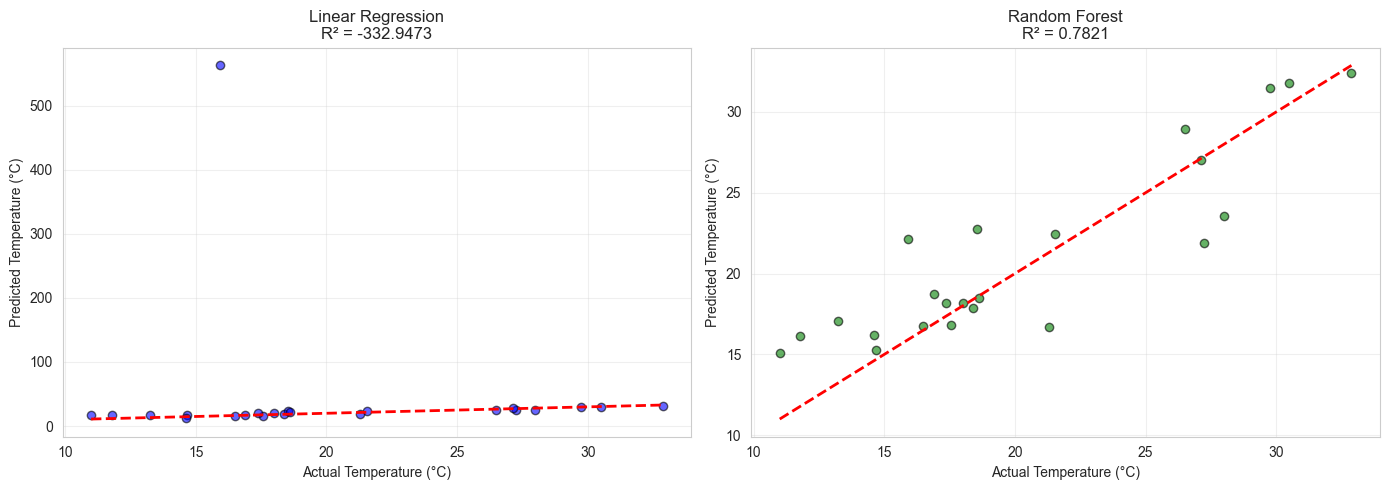

In [27]:
# Actual vs Predicted - Linear Regression
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_original, y_pred_lr_original, alpha=0.6, color='blue', edgecolors='k')
axes[0].plot([y_test_original.min(), y_test_original.max()], 
             [y_test_original.min(), y_test_original.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Temperature (°C)')
axes[0].set_ylabel('Predicted Temperature (°C)')
axes[0].set_title(f'Linear Regression\nR² = {metrics_lr["R2"]:.4f}')
axes[0].grid(True, alpha=0.3)

# Actual vs Predicted - Random Forest
axes[1].scatter(y_test_original, y_pred_rf_original, alpha=0.6, color='green', edgecolors='k')
axes[1].plot([y_test_original.min(), y_test_original.max()], 
             [y_test_original.min(), y_test_original.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Temperature (°C)')
axes[1].set_ylabel('Predicted Temperature (°C)')
axes[1].set_title(f'Random Forest\nR² = {metrics_rf["R2"]:.4f}')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('04_predictions_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

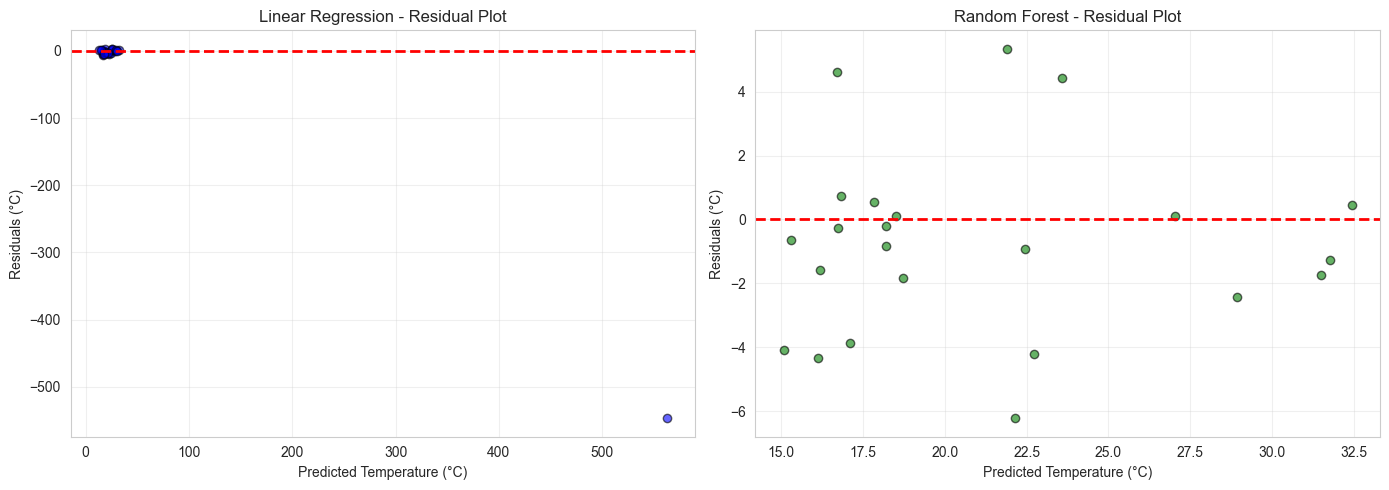

In [25]:
# Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

residuals_lr = y_test_original - y_pred_lr_original
residuals_rf = y_test_original - y_pred_rf_original

axes[0].scatter(y_pred_lr_original, residuals_lr, alpha=0.6, color='blue', edgecolors='k')
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted Temperature (°C)')
axes[0].set_ylabel('Residuals (°C)')
axes[0].set_title('Linear Regression - Residual Plot')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_pred_rf_original, residuals_rf, alpha=0.6, color='green', edgecolors='k')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Temperature (°C)')
axes[1].set_ylabel('Residuals (°C)')
axes[1].set_title('Random Forest - Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('05_residuals.png', dpi=300, bbox_inches='tight')
plt.show()


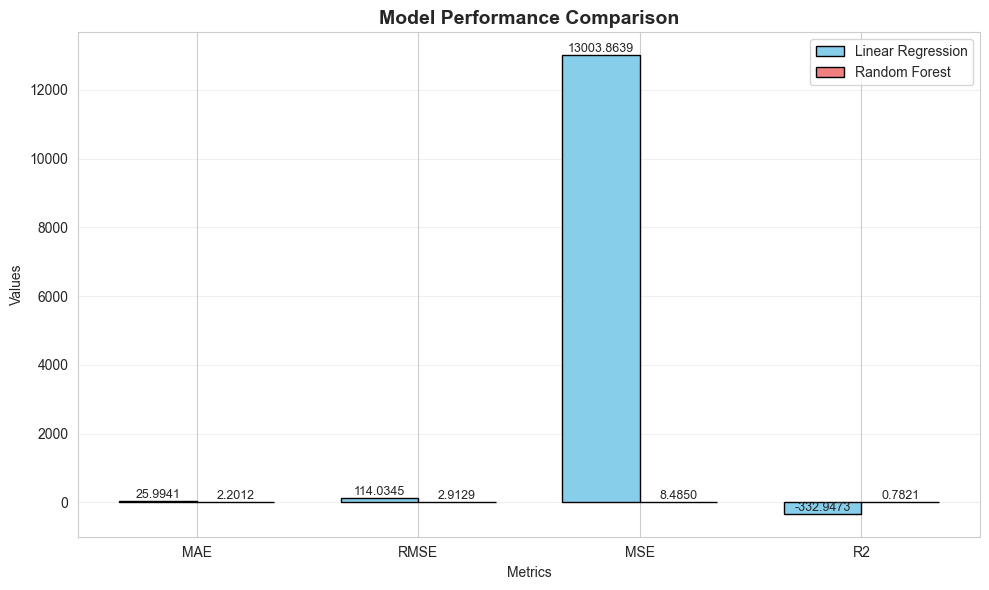

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

metrics_names = list(metrics_lr.keys())
lr_values = list(metrics_lr.values())
rf_values = list(metrics_rf.values())

x = np.arange(len(metrics_names))
width = 0.35

bars1 = ax.bar(x - width/2, lr_values, width, label='Linear Regression', color='skyblue', edgecolor='black')
bars2 = ax.bar(x + width/2, rf_values, width, label='Random Forest', color='lightcoral', edgecolor='black')

ax.set_xlabel('Metrics')
ax.set_ylabel('Values')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('06_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

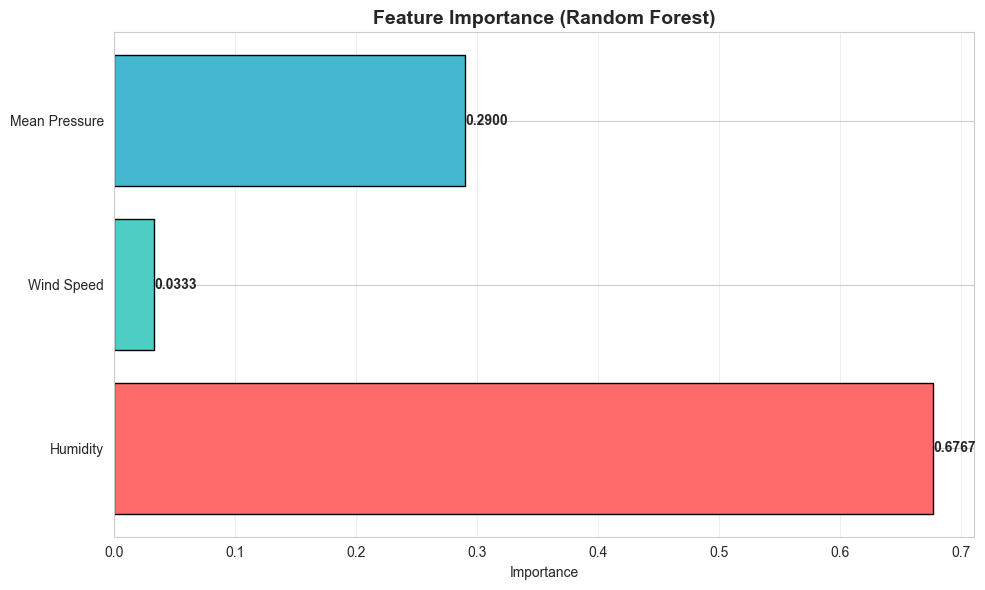

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
feature_names = ['Humidity', 'Wind Speed', 'Mean Pressure']
importances = model_rf.feature_importances_

bars = ax.barh(feature_names, importances, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], edgecolor='black')
ax.set_xlabel('Importance')
ax.set_title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f'{width:.4f}', ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('07_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()


In [40]:
# verdicts
print("10. CONCLUSIONS AND INSIGHTS")

print("\n DATA SUMMARY:")
print(f"  • Total records processed: {len(df)}")
print(f"  • Date range: {df['date'].min()} to {df['date'].max()}")
print(f"  • Features used: Humidity, Wind Speed, Mean Pressure")
print(f"  • Target variable: Mean Temperature")

print("\n MODEL PERFORMANCE:")
if metrics_rf['R2'] > metrics_lr['R2']:
    print(f"  • Best Model: Random Forest (R² = {metrics_rf['R2']:.4f})")
    print(f"  • RMSE: {metrics_rf['RMSE']:.4f}°C")
    print(f"  • MAE: {metrics_rf['MAE']:.4f}°C")
else:
    print(f"  • Best Model: Linear Regression (R² = {metrics_lr['R2']:.4f})")
    print(f"  • RMSE: {metrics_lr['RMSE']:.4f}°C")
    print(f"  • MAE: {metrics_lr['MAE']:.4f}°C")

print("\n KEY INSIGHTS:")
print(f"  • Correlation with Temperature: {corr_matrix['meantemp'].sort_values(ascending=False).to_string()}")
print(f"  • Most important feature: {feature_names[np.argmax(importances)]}")
print(f"  • Temperature range: {df['meantemp'].min():.2f}°C to {df['meantemp'].max():.2f}°C")

print("\n All visualizations saved as PNG files (01-07_*.png)")

10. CONCLUSIONS AND INSIGHTS

 DATA SUMMARY:
  • Total records processed: 114
  • Date range: 2017-01-01 to 2017-04-24
  • Features used: Humidity, Wind Speed, Mean Pressure
  • Target variable: Mean Temperature

 MODEL PERFORMANCE:
  • Best Model: Random Forest (R² = 0.7821)
  • RMSE: 2.9129°C
  • MAE: 2.2012°C

 KEY INSIGHTS:
  • Correlation with Temperature: meantemp        1.000000
wind_speed      0.217743
meanpressure    0.030682
humidity       -0.857726
  • Most important feature: Humidity
  • Temperature range: 11.00°C to 34.50°C

 All visualizations saved as PNG files (01-07_*.png)
